# Module 3 · Lab 3.2 — Embeddings & Semantic Search
## From "what is a vector?" to a working search engine over 300 documents

---

### Lab overview

Every RAG system, recommender, and retrieval tool in this course rests on **one
idea**: text can be turned into a vector of numbers whose *geometry* encodes
*meaning*. Sentences that mean similar things land close together; unrelated
sentences land far apart. Master this and the rest of the RAG track is just
engineering.

This lab runs in **two parts** that build on each other:

| | Part | You will… |
|---|---|---|
| **A** | **Understand embeddings** | Generate vectors, measure similarity with cosine, compare models (OpenAI small/large vs open-source), shrink vectors, and *see* the space in 2-D |
| **B** | **Build a search engine** | Embed a ~300-document banking knowledge base, index it with **FAISS**, search it in natural language, beat keyword search, and **measure** retrieval quality |

The hinge between them: in Part A you'll write a *naive* search that scans every
vector on every query. That's fine for 8 products — but it collapses at scale.
Part B replaces it with a real vector index.

### Learning objectives
By the end you can:
1. Generate embeddings with OpenAI's API and interpret raw vectors
2. Compute and read **cosine similarity** (and know when dot-product / Euclidean differ)
3. Choose an embedding model on **quality, cost, and dimensionality**
4. Build and query a **FAISS** index for fast top-K retrieval
5. Evaluate a retriever with **Precision@K, Recall@K, and MRR**

### Prerequisites
- An **`OPENAI_API_KEY`** (embeddings + a little `gpt-4.1-mini` for corpus generation)
- The workshop VM (keys in the workshop's `.env` file), Colab, or a local `.env`. No GPU required.

> 🗺️ **Workshop run-list.**
> **Live in session:** §1–6 (embeddings, cosine, distance metrics), §9–13 (build, index and search a 300-document FAISS store; semantic vs keyword), §16 conclusion
> **After the session:** §7 choosing an embedding model, §8 the t-SNE map, §14 Precision@K / Recall@K / MRR, §15 approximate nearest neighbour — kept in full so you can finish at your own pace (marked ⏭️).

## 1. Setup — install dependencies

In [1]:
# 📦 Packages this notebook needs. On the workshop VM they are pre-installed from
# the workshop's requirements.txt, so the install line below stays commented out.
# Running somewhere else (Colab, your own laptop)? Uncomment it and run this cell once.
# !pip install -qU faiss-cpu matplotlib numpy openai pandas python-dotenv scikit-learn sentence-transformers

from importlib.metadata import PackageNotFoundError, version

NOTEBOOK_PACKAGES = [
    "faiss-cpu",
    "matplotlib",
    "numpy",
    "openai",
    "pandas",
    "python-dotenv",
    "scikit-learn",
    "sentence-transformers",
]
for package_name in NOTEBOOK_PACKAGES:
    try:
        print(f"{package_name:<26} {version(package_name)}")
    except PackageNotFoundError:
        print(f"{package_name:<26} NOT INSTALLED — uncomment the !pip line above")

faiss-cpu                  1.15.1
matplotlib                 3.11.2
numpy                      2.5.3
openai                     2.54.0
pandas                     2.3.3
python-dotenv              1.2.3
scikit-learn               1.9.1
sentence-transformers      6.1.0


## 2. Load your API key

Colab-Secrets-first / `.env`-fallback — the same loader used in every lab of this workshop. On
Colab, add `OPENAI_API_KEY` in the 🔑 **Secrets** panel; locally, put it in a
`.env` file at (or above) your working directory.

In [2]:
import os

# Where to create each key. The trainer supplies OPENAI_API_KEY on the workshop VM;
# you create any other key yourself and add it to the workshop's .env file as KEY_NAME=value.
KEY_SIGNUP_PAGES = {
    "OPENAI_API_KEY": "supplied on the workshop VM (elsewhere: https://platform.openai.com/api-keys)",
    "TAVILY_API_KEY": "https://app.tavily.com (free tier)",
    "GROQ_API_KEY": "https://console.groq.com/keys (free tier)",
    "WEATHER_API_KEY": "https://www.weatherapi.com/signup.aspx (free tier)",
    "LANGSMITH_API_KEY": "https://smith.langchain.com -> Settings -> API Keys (free tier)",
    "ANTHROPIC_API_KEY": "https://console.anthropic.com/settings/keys",
    "GEMINI_API_KEY": "https://aistudio.google.com/app/apikey",
}


def load_keys(required):
    """Load API keys from Colab Secrets (on Colab) or a local .env file (elsewhere).

    Prints one line per key, then stops with instructions if a required key is missing.

    Args:
        required: the environment-variable names this lab needs.
    """
    try:
        from google.colab import userdata          # running on Google Colab
        for key_name in required:
            try:
                os.environ[key_name] = userdata.get(key_name)
            except Exception:
                pass                                 # not set in Colab Secrets
        source = "Colab Secrets"
    except ImportError:                              # the workshop VM, or any local machine
        from dotenv import find_dotenv, load_dotenv
        load_dotenv(find_dotenv(usecwd=True))        # searches upward for the workshop's .env file
        source = ".env / environment"
    print(f"\U0001F511 Key source: {source}")
    for key_name in required:
        print(f"   {key_name:<22} {'✅' if os.environ.get(key_name) else '❌ MISSING'}")
    missing_keys = [key_name for key_name in required if not os.environ.get(key_name)]
    if missing_keys:
        instructions = "\n".join(
            f"  {key_name}: {KEY_SIGNUP_PAGES.get(key_name, 'see README.md in the workshop folder')}"
            for key_name in missing_keys)
        raise RuntimeError(
            "This lab needs API keys that are not set yet. Create each one, add it to\n"
            "the workshop's .env file as KEY_NAME=value, then re-run this cell:\n" + instructions)

load_keys(["OPENAI_API_KEY"])

🔑 Key source: .env / environment
   OPENAI_API_KEY         ✅


## 3. Initialize the client & the *one* embedding helper

We define a single `embed()` function and use it **everywhere** in this lab — for
8 product names in Part A and for 300 documents in Part B. It batches (OpenAI
accepts up to 2048 inputs per call), accepts an optional `dimensions` argument
(for the shrink-the-vector demo in §7c), and returns a `float32` NumPy array —
the dtype FAISS wants.

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

openai_client = OpenAI()

EMBED_SMALL = "text-embedding-3-small"   # 1536 dims — fast, cheap, the default workhorse
EMBED_LARGE = "text-embedding-3-large"   # 3072 dims — higher quality, ~6x the cost
GENERATION_MODEL = "gpt-4.1-mini"        # used once, to synthesize the Part-B corpus

def embed(texts, model=EMBED_SMALL, dimensions=None, batch_size=500):
    """Embed text(s) with OpenAI. Accepts a str or list; returns an (n, d) float32 array."""
    if isinstance(texts, str):
        texts = [texts]
    vectors = []
    for start_index in range(0, len(texts), batch_size):
        batch = texts[start_index:start_index + batch_size]
        request_arguments = {"model": model, "input": batch}
        if dimensions:
            request_arguments["dimensions"] = dimensions   # Matryoshka truncation (see §7c)
        response = openai_client.embeddings.create(**request_arguments)
        vectors.extend(item.embedding for item in response.data)
    return np.array(vectors, dtype="float32")

def show_similarity_heatmap(texts, similarity_matrix, title="Cosine similarity", max_length=45):
    """Draw an annotated heatmap of a pairwise similarity matrix."""
    labels = [text[:max_length] + "…" if len(text) > max_length else text for text in texts]
    figure, axes = plt.subplots(figsize=(9, 7))
    heatmap_image = axes.imshow(similarity_matrix, cmap="YlOrRd", vmin=0, vmax=1)
    axes.set_xticks(range(len(labels))); axes.set_yticks(range(len(labels)))
    axes.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    axes.set_yticklabels(labels, fontsize=8)
    for row_index in range(len(labels)):
        for column_index in range(len(labels)):
            cell_value = similarity_matrix[row_index][column_index]
            axes.text(column_index, row_index, f"{cell_value:.2f}", ha="center", va="center",
                      fontsize=7, color="white" if cell_value > 0.7 else "black")
    plt.colorbar(heatmap_image, ax=axes, label="Cosine similarity")
    plt.title(title, fontsize=13); plt.tight_layout(); plt.show()

print("Toolkit ready ✅  (embed + heatmap)")

Toolkit ready ✅  (embed + heatmap)


---
# Part A — Understanding Embeddings

Before we build anything, we develop intuition: what a vector *is*, how to
measure "closeness," which model to pick, and what the space actually looks like.

## 4. Your first embeddings — and what cosine similarity means

**Business scenario.** A retail bank wants a product-recommendation engine. When
a customer describes a need, the system should surface the most relevant product.
We start by embedding eight product descriptions and looking at the raw numbers.

In [4]:
products = [
    "High-yield savings account with 4.5% APY, no minimum balance, FDIC insured up to $250,000",
    "Fixed deposit account with guaranteed returns, lock-in periods of 6 to 60 months",
    "Retirement pension plan with tax benefits, employer matching, and diversified fund options",
    "Personal home loan at competitive interest rates with flexible EMI options up to 30 years",
    "Business line of credit for working capital needs, revolving facility up to $500,000",
    "Student education loan covering tuition, living expenses, with grace period after graduation",
    "Credit card with cashback rewards on dining, travel, and online shopping",
    "Travel insurance covering medical emergencies, trip cancellation, and lost baggage abroad",
]

product_embeddings = embed(products)              # (8, 1536) float32
print(f"Embedding matrix: {product_embeddings.shape}  →  each product is a {product_embeddings.shape[1]}-dim vector")
print("First 10 numbers of product #0:\n", product_embeddings[0][:10])

Embedding matrix: (8, 1536)  →  each product is a 1536-dim vector
First 10 numbers of product #0:
 [-0.00508118  0.01863098 -0.01277924  0.09118652 -0.00793457  0.00791168
 -0.0117569   0.05334473  0.02687073 -0.04049683]


An embedding is just that list of floats. On its own it's meaningless — its
value is **relative**: how it compares to other vectors. The standard comparison
for text is **cosine similarity**, the cosine of the angle between two vectors
(1.0 = same direction/meaning, 0 = unrelated).

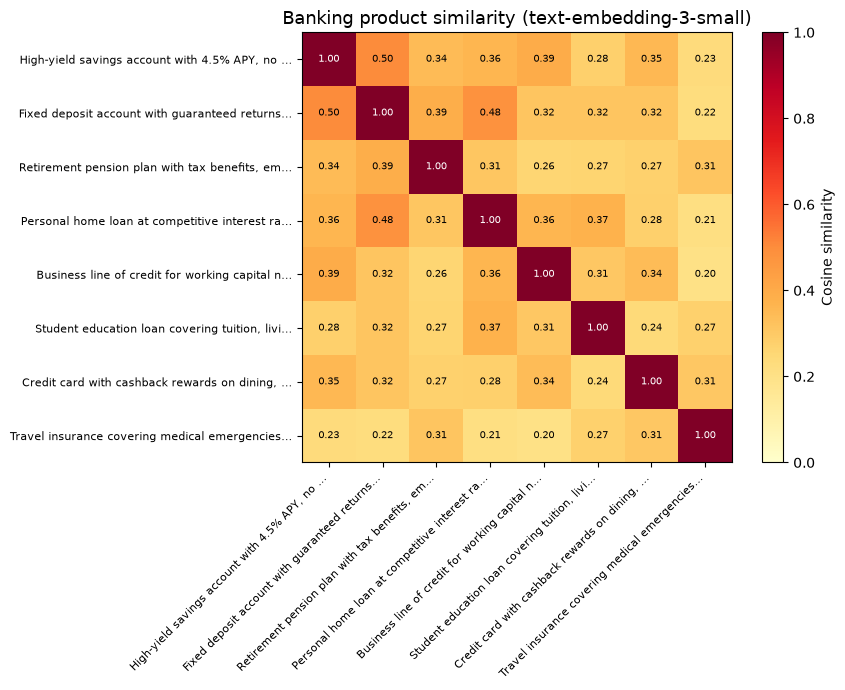

In [5]:
similarity_matrix = cosine_similarity(product_embeddings)
show_similarity_heatmap(products, similarity_matrix, title="Banking product similarity (text-embedding-3-small)")

**How to read it**
- **1.0** on the diagonal — every text is identical to itself.
- **0.5–0.85** — related concepts (savings account ↔ fixed deposit).
- **0.3–0.5** — loosely related (both financial, different category).
- **< 0.3** — semantically distant.

## 5. Semantic similarity in action — a *naive* search 🔎

Now the useful part: embed a **customer query**, compare it to every product, and
take the highest cosine score. Note that the customer's words barely overlap with
the product text — yet meaning still matches. That's the whole point of embeddings
over keyword search.

In [6]:
customer_queries = [
    "I want to grow my money safely with good interest",
    "I need money to buy my first house",
    "My daughter is going to college next year and needs financial help",
    "I'm planning a trip to Europe and want protection against emergencies",
    "I want to save for my retirement with tax advantages",
]

query_embeddings = embed(customer_queries)
scores = cosine_similarity(query_embeddings, product_embeddings)   # (5 queries, 8 products)

print("🏦 Customer query → best-matching product\n")
for query_index, query in enumerate(customer_queries):
    best_product_index = int(np.argmax(scores[query_index]))
    print(f'"{query}"\n   → {products[best_product_index]}\n   → score {scores[query_index][best_product_index]:.3f}\n')

🏦 Customer query → best-matching product

"I want to grow my money safely with good interest"
   → Fixed deposit account with guaranteed returns, lock-in periods of 6 to 60 months
   → score 0.448

"I need money to buy my first house"
   → Personal home loan at competitive interest rates with flexible EMI options up to 30 years
   → score 0.319

"My daughter is going to college next year and needs financial help"
   → Student education loan covering tuition, living expenses, with grace period after graduation
   → score 0.396

"I'm planning a trip to Europe and want protection against emergencies"
   → Travel insurance covering medical emergencies, trip cancellation, and lost baggage abroad
   → score 0.597

"I want to save for my retirement with tax advantages"
   → Retirement pension plan with tax benefits, employer matching, and diversified fund options
   → score 0.598



### 💡 Hold this thought
That loop **is** a semantic search engine. But look at what it does: for *each*
query it computes similarity against **every** product, and it keeps **all**
vectors in memory as a plain array. With 8 products that's nothing. With
300,000 documents it's a full scan per query and a memory problem.

That limitation is exactly what **Part B** fixes with a vector index. First, let's
finish building intuition.

## 6. Cosine, dot product, or Euclidean?

Cosine is the default for text — but it helps to see why. Here we flag
**near-duplicate e-commerce listings** and compare three metrics on the same pairs.

**Business scenario.** A marketplace wants to detect duplicate listings posted by
different sellers.

In [7]:
from sklearn.metrics.pairwise import euclidean_distances

listings = [
    "Apple iPhone 15 Pro Max 256GB Natural Titanium Unlocked",          # 0
    "iPhone 15 Pro Max 256 GB Titanium - Factory Unlocked Brand New",   # 1  near-duplicate of 0
    "Samsung Galaxy S24 Ultra 512GB Titanium Gray Unlocked",            # 2
    "Apple MacBook Pro 14-inch M3 Pro chip 18GB RAM 512GB SSD",         # 3
    "Sony WH-1000XM5 Wireless Noise Cancelling Headphones Black",       # 4
    "Bose QuietComfort Ultra Headphones Wireless Noise Cancelling",     # 5  same category as 4
]
listing_embeddings = embed(listings)
cosine_scores = cosine_similarity(listing_embeddings)
dot_products = listing_embeddings @ listing_embeddings.T   # raw dot product (magnitude-sensitive)
euclidean_matrix = euclidean_distances(listing_embeddings) # straight-line distance (lower = closer)

pairs = [
    (0, 1, "iPhone listing vs its duplicate"),
    (0, 2, "iPhone vs Samsung (same category)"),
    (4, 5, "Sony vs Bose headphones (competitors)"),
    (0, 3, "iPhone vs MacBook (same brand, diff product)"),
    (0, 4, "iPhone vs headphones (unrelated)"),
]
print(f"{'Pair':<42}{'Cosine':>9}{'Dot':>9}{'Euclid':>9}")
print("─" * 69)
for first_index, second_index, label in pairs:
    print(f"{label:<42}"
          f"{cosine_scores[first_index][second_index]:>9.3f}"
          f"{dot_products[first_index][second_index]:>9.3f}"
          f"{euclidean_matrix[first_index][second_index]:>9.3f}")

Pair                                         Cosine      Dot   Euclid
─────────────────────────────────────────────────────────────────────
iPhone listing vs its duplicate               0.876    0.877    0.497
iPhone vs Samsung (same category)             0.670    0.670    0.813
Sony vs Bose headphones (competitors)         0.649    0.649    0.837
iPhone vs MacBook (same brand, diff product)    0.500    0.500    1.000
iPhone vs headphones (unrelated)              0.306    0.306    1.178


| Metric | Formula | Range | Best for |
|---|---|---|---|
| **Cosine similarity** | (A·B) / (‖A‖‖B‖) | [-1, 1] | Meaning, independent of text length — **the text default** |
| **Dot product** | Σ aᵢbᵢ | (-∞, ∞) | When magnitude carries signal (e.g. weighted importance) |
| **Euclidean distance** | ‖A − B‖₂ | [0, ∞) | Absolute distance; lower = closer |

> OpenAI embeddings are (near) unit-length, so **cosine and dot product rank the
> same way** — which is why FAISS in Part B normalizes vectors and then uses a
> fast inner-product index to *get* cosine.

> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

## 7. Choosing an embedding model — quality, cost, and size

Three practical dials decide which model you ship. We look at all three on
domain text, back to back.

### 7a · Small vs large (nuance vs cost)
`text-embedding-3-large` is ~2× the dimensions and ~6× the price of `-small`. Does
it separate *subtly* different texts better? We test on insurance claims where
some pairs describe the **same event in different words**.

In [8]:
claims = [
    "Patient underwent cardiac bypass surgery after acute myocardial infarction",   # 0
    "Emergency heart surgery performed following a severe heart attack",            # 1  == 0, layman terms
    "Routine annual health checkup with blood work and ECG",                        # 2
    "Vehicle rear-ended at traffic signal, driver sustained whiplash injury",       # 3
    "Car accident at intersection caused neck and back injuries to driver",         # 4  == 3, reworded
    "Water damage to basement due to pipe burst during winter freeze",              # 5
    "Frozen pipes caused flooding in ground floor of insured property",             # 6  == 5, reworded
    "Laptop stolen from hotel room during business trip",                           # 7
]
small_embeddings = embed(claims, EMBED_SMALL)
large_embeddings = embed(claims, EMBED_LARGE)
small_similarity = cosine_similarity(small_embeddings)
large_similarity = cosine_similarity(large_embeddings)

pairs = [
    (0, 1, "Heart surgery (medical vs layman)"),
    (3, 4, "Car accident (same event, reworded)"),
    (5, 6, "Pipe burst / flooding (reworded)"),
    (0, 3, "Heart surgery vs car accident"),
    (2, 7, "Health checkup vs laptop theft"),
]
print(f"{'Pair':<38}{'small':>8}{'large':>8}{'Δ':>8}")
print("─" * 62)
for first_index, second_index, label in pairs:
    small_score = small_similarity[first_index][second_index]
    large_score = large_similarity[first_index][second_index]
    print(f"{label:<38}{small_score:>8.3f}{large_score:>8.3f}{large_score - small_score:>+8.3f}")

Pair                                     small   large       Δ
──────────────────────────────────────────────────────────────
Heart surgery (medical vs layman)        0.648   0.631  -0.017
Car accident (same event, reworded)      0.688   0.701  +0.013
Pipe burst / flooding (reworded)         0.614   0.646  +0.033
Heart surgery vs car accident            0.237   0.188  -0.049
Health checkup vs laptop theft           0.130   0.149  +0.019


| Factor | `text-embedding-3-small` | `text-embedding-3-large` |
|---|---|---|
| Dimensions | 1,536 | 3,072 |
| Cost (approx) | ~$0.02 / 1M tokens | ~$0.13 / 1M tokens |
| Storage | 2× less | 2× more |
| Best for | Prototyping, most production RAG | High-precision / nuanced retrieval |

> The gains are real but **small** for most text. Reach for `-large` only when
> evaluation shows `-small` confusing things you need kept apart.

### 7b · OpenAI vs open-source (cost & privacy)
A hosted API isn't the only option. **Sentence-Transformers** run locally, free,
offline — data never leaves your machine. We match patient questions to FAQ
entries with both and compare accuracy.

*(First run downloads the ~90 MB `all-MiniLM-L6-v2` model.)*

In [9]:
from sentence_transformers import SentenceTransformer

sentence_transformer = SentenceTransformer("all-MiniLM-L6-v2")   # 384 dims, local, no API key
print("Loaded all-MiniLM-L6-v2 (384-dim) ✅")

faq_entries = [
    "What are the side effects of metformin?",
    "How do I schedule a telehealth appointment?",
    "Is my MRI scan covered by insurance?",
    "What should I eat before a blood test?",
    "How do I refill my prescription online?",
]
patient_questions = [
    "I started taking metformin and I feel nauseous, is that normal?",
    "Can I see my doctor over video call instead of going to the clinic?",
    "Will my health plan pay for the imaging test my doctor ordered?",
    "Do I need to fast before getting my blood drawn tomorrow?",
    "I ran out of my medication, how can I get more without visiting the pharmacy?",
]

# OpenAI vs local — each patient question should match the FAQ at the same index
openai_similarity = cosine_similarity(embed(patient_questions), embed(faq_entries))
local_similarity = cosine_similarity(
    sentence_transformer.encode(patient_questions),
    sentence_transformer.encode(faq_entries),
)
openai_hits = sum(int(np.argmax(openai_similarity[index]) == index) for index in range(len(patient_questions)))
local_hits = sum(int(np.argmax(local_similarity[index]) == index) for index in range(len(patient_questions)))
print(f"\nOpenAI (1536-d):            {openai_hits}/{len(patient_questions)} correct")
print(f"MiniLM local (384-d):       {local_hits}/{len(patient_questions)} correct")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\participant\.venvs\workshop\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\participant\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded all-MiniLM-L6-v2 (384-dim) ✅



OpenAI (1536-d):            5/5 correct
MiniLM local (384-d):       5/5 correct


| Factor | OpenAI `-3-small` | Sentence-Transformers `MiniLM` |
|---|---|---|
| Cost | ~$0.02 / 1M tokens | Free (local compute) |
| Dimensions | 1,536 | 384 |
| Latency | Network round-trip | Local (fast on CPU) |
| Privacy | Data sent to API | **Data stays on-prem** |
| Offline | ❌ | ✅ |

> For an easy task both score full marks. Open-source shines when **privacy,
> cost-at-scale, or offline** matter; hosted models pull ahead on the hardest
> semantic distinctions.

### 7c · Shrinking vectors — the Matryoshka trick
`text-embedding-3` models are trained so you can **truncate** dimensions and keep
most of the signal. Fewer dims = less storage and faster search. We measure how a
near-duplicate pair's similarity holds up as we cut dimensions.

In [10]:
near_duplicate_pair = [
    "Online purchase at Amazon for electronics",
    "E-commerce transaction on Amazon for gadgets",   # near-duplicate of the above
]
print(f"{'Dimensions':>11}{'Cosine':>9}{'Bytes/vec':>12}")
print("─" * 32)
for dimension in (256, 512, 1024, 1536):
    truncated_embeddings = embed(near_duplicate_pair, dimensions=dimension)
    print(f"{dimension:>11}{cosine_similarity(truncated_embeddings)[0][1]:>9.3f}{dimension * 4:>12}")

 Dimensions   Cosine   Bytes/vec
────────────────────────────────


        256    0.795        1024


        512    0.789        2048


       1024    0.755        4096


       1536    0.754        6144


**Takeaway.** 512 — sometimes 256 — dims retain most of the quality at a
fraction of the storage. At millions of vectors, that directly cuts your vector-DB bill.

## 8. Seeing the space — a 2-D map with t-SNE

Vectors live in 1,536 dimensions; our eyes do not. **t-SNE** projects them to 2-D
while preserving neighbourhoods, so we can *see* whether same-category texts
cluster. If embeddings are working, colours should group.

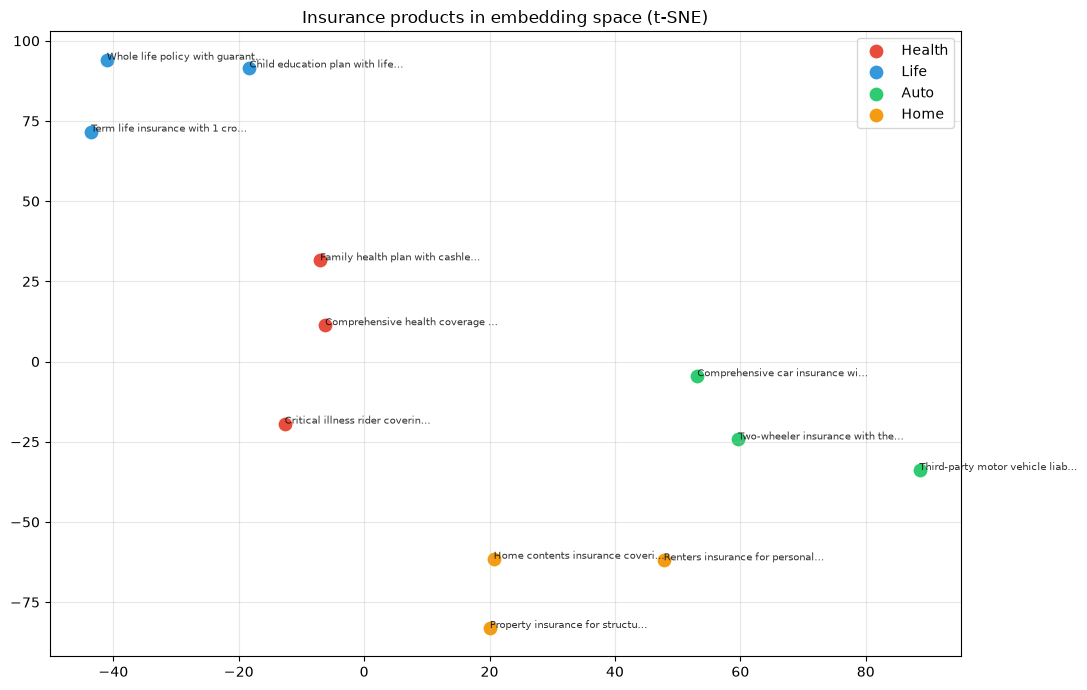

In [11]:
from sklearn.manifold import TSNE

labelled_products = [
    ("Comprehensive health coverage including hospitalization and surgery", "Health"),
    ("Family health plan with cashless treatment at 5000+ hospitals", "Health"),
    ("Critical illness rider covering cancer, heart attack, stroke", "Health"),
    ("Term life insurance with 1 crore coverage at affordable premiums", "Life"),
    ("Whole life policy with guaranteed returns and death benefit", "Life"),
    ("Child education plan with life cover and maturity benefits", "Life"),
    ("Comprehensive car insurance with zero depreciation and roadside assistance", "Auto"),
    ("Third-party motor vehicle liability coverage as per regulations", "Auto"),
    ("Two-wheeler insurance with theft protection and personal accident cover", "Auto"),
    ("Home contents insurance covering fire, theft, and natural disasters", "Home"),
    ("Property insurance for structural damage including earthquake coverage", "Home"),
    ("Renters insurance for personal belongings and liability protection", "Home"),
]
texts = [text for text, _ in labelled_products]
categories = [category for _, category in labelled_products]

coordinates = TSNE(n_components=2, random_state=42, perplexity=4).fit_transform(embed(texts))
colors = {"Health": "#e74c3c", "Life": "#3498db", "Auto": "#2ecc71", "Home": "#f39c12"}

plt.figure(figsize=(11, 7))
for category, color in colors.items():
    category_points = coordinates[[index for index, category_name in enumerate(categories) if category_name == category]]
    plt.scatter(category_points[:, 0], category_points[:, 1], c=color, label=category, s=120, edgecolors="white")
for index, text in enumerate(texts):
    plt.annotate(text[:30] + "…", (coordinates[index, 0], coordinates[index, 1]), fontsize=7, alpha=0.8)
plt.legend(); plt.title("Insurance products in embedding space (t-SNE)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

Same-colour points sit together and the four families separate — visual proof
that embeddings capture semantic groups. That clustering is exactly what makes
**retrieval** work, which is what we build next.

---
# Part B — Build a Semantic Search Engine

The naive search in §5 rescans every vector per query and holds them all in a
Python list. To serve a real knowledge base we need a **vector index**: a data
structure built for fast top-K nearest-neighbour lookup. We'll use **FAISS**
(Facebook AI Similarity Search) over a realistic ~300-document banking corpus.

## 9. Build a realistic corpus (~300 banking documents)

We hand-write **60 core documents** with known content (so we can grade retrieval
later) and use `gpt-4.1-mini` to synthesize the rest across banking sub-domains,
reaching ~300.

In [12]:
core_documents = [
    # --- Savings & Deposits (0-9) ---
    "Our Premium Savings Account offers 4.5% APY with no minimum balance requirement and is FDIC insured up to $250,000.",
    "The Youth Savings Account is designed for customers aged 13-25, with no monthly fees and a 3.2% interest rate.",
    "Fixed deposits are available with tenures ranging from 6 months to 5 years. Early withdrawal incurs a 1% penalty on earned interest.",
    "Senior Citizen Savings Scheme offers an additional 0.50% interest rate above regular FD rates for customers over 60.",
    "Our recurring deposit plan allows monthly contributions of $50 to $10,000 with auto-debit from your checking account.",
    "The money market account requires a $2,500 minimum balance and provides check-writing privileges with 4.1% APY.",
    "Certificate of Deposit (CD) rates: 6-month at 4.0%, 12-month at 4.3%, 24-month at 4.5%, 60-month at 4.8%.",
    "Interest on savings accounts is compounded daily and credited monthly. Rate is variable and subject to change.",
    "Joint savings accounts allow up to 4 co-holders with equal rights. All holders must present valid ID at branch.",
    "Our zero-balance savings account is available for salaried individuals with direct deposit setup from their employer.",
    # --- Loans (10-19) ---
    "Home loans are available at 6.5% fixed rate for up to 30 years. Minimum down payment is 10% for first-time buyers.",
    "Personal loans range from $1,000 to $50,000 with terms of 12-60 months. No collateral required for loans under $25,000.",
    "Auto loans offer competitive rates starting at 5.9% APR for new vehicles and 6.9% for used vehicles up to 5 years old.",
    "Student education loans cover tuition, books, housing, and living expenses. Repayment begins 6 months after graduation.",
    "Business term loans are available from $25,000 to $500,000 with fixed or variable rate options for established businesses.",
    "Home equity line of credit (HELOC) allows borrowing against your home's equity at prime rate plus 1.5%.",
    "Loan refinancing options are available for existing customers looking to reduce their monthly EMI or interest rate.",
    "Agricultural loans support farming equipment purchase, crop financing, and land improvement projects at subsidized rates.",
    "Debt consolidation loans combine multiple high-interest debts into a single monthly payment at lower interest rates.",
    "Bridge loans provide short-term financing for 6-12 months while customers transition between property purchases.",
    # --- Credit Cards (20-29) ---
    "The Platinum Credit Card offers 3% cashback on dining, 2% on travel, and 1% on all other purchases with no annual fee for the first year.",
    "Our Business Credit Card provides 5x reward points on office supplies, telecom, and cloud services for small businesses.",
    "The Student Credit Card has a $1,000 credit limit with no annual fee and 1.5% cashback on all purchases.",
    "Premium travel card includes complimentary airport lounge access at 1000+ lounges worldwide and travel insurance up to $500,000.",
    "Credit card balance transfer facility available at 0% APR for first 15 months. Transfer fee is 3% of amount transferred.",
    "Contactless payments are enabled on all credit cards. Daily contactless transaction limit is $500 without PIN.",
    "Credit card EMI conversion is available for transactions above $200. Convert to 3, 6, 9, or 12-month installments.",
    "Card replacement for lost or stolen cards is free. Emergency card issuance within 48 hours at any branch.",
    "Credit limit increase requests can be submitted online. Processing takes 3-5 business days with no impact on credit score.",
    "All credit cards come with fraud protection. Unauthorized transactions reported within 48 hours result in zero liability.",
    # --- Digital Banking (30-39) ---
    "Mobile banking app supports fingerprint and face ID login, instant fund transfers, bill payments, and investment tracking.",
    "Online account opening requires a valid government-issued photo ID and can be completed in under 10 minutes.",
    "UPI payments are supported with daily transaction limits of $2,000 for peer-to-peer and $5,000 for merchant payments.",
    "Digital wallet integration supports Apple Pay, Google Pay, and Samsung Pay for contactless in-store payments.",
    "Net banking platform provides account statements, tax certificates, and loan account details downloadable as PDF.",
    "Two-factor authentication is mandatory for all online transactions above $100. OTP is sent via SMS and email.",
    "Scheduled recurring payments can be set up for rent, utilities, subscriptions, and loan EMIs via net banking.",
    "The chatbot assistant is available 24/7 for balance inquiries, recent transactions, and basic service requests.",
    "Remote deposit capture allows check deposits via mobile app by photographing the front and back of the check.",
    "Account alerts can be configured for low balance warnings, large transactions, login attempts, and payment reminders.",
    # --- Insurance (40-49) ---
    "Term life insurance policies available from $100,000 to $5 million coverage with premiums starting at $15/month.",
    "Health insurance family floater plan covers spouse and up to 3 children with cashless hospitalization at network hospitals.",
    "Comprehensive car insurance covers own damage, third-party liability, personal accident, and roadside assistance.",
    "Home insurance protects against fire, theft, natural disasters, and accidental damage to structure and contents.",
    "Travel insurance covers medical emergencies abroad, trip cancellation, delayed flights, and lost baggage up to $50,000.",
    "Critical illness insurance pays a lump sum on diagnosis of cancer, heart attack, stroke, or organ transplant.",
    "Professional liability insurance for doctors, lawyers, and consultants covers malpractice claims up to $2 million.",
    "Cyber insurance for businesses covers data breach costs, ransomware payments, and business interruption losses.",
    "Pet insurance covers veterinary bills, surgery, hospitalization, and preventive care for dogs and cats.",
    "Group health insurance for companies with 10+ employees offers discounted premiums and customizable coverage options.",
    # --- Compliance & Policies (50-59) ---
    "KYC verification requires government-issued photo ID, proof of address not older than 3 months, and a recent photograph.",
    "Anti-money laundering (AML) policy requires reporting of all cash transactions exceeding $10,000 to the regulatory authority.",
    "Customer complaint resolution turnaround time is 7 business days for standard complaints and 24 hours for fraud-related issues.",
    "Account dormancy policy: accounts with no transactions for 24 months are classified as dormant and require reactivation.",
    "GDPR compliance ensures all customer data is encrypted at rest and in transit. Data deletion requests are processed within 30 days.",
    "Wire transfer processing: domestic transfers complete within same business day. International wires take 2-5 business days.",
    "Check clearance timeline: local checks clear in 1-2 business days. Outstation checks may take up to 5 business days.",
    "Safe deposit box rental is available in three sizes: small ($60/year), medium ($120/year), and large ($250/year).",
    "Nomination facility is available for savings accounts, fixed deposits, and locker services. Nomination can be changed anytime at branch.",
    "Power of attorney holders can operate accounts with notarized POA document. POA does not apply to locker access.",
]
print(f"Core documents (hand-written, graded later): {len(core_documents)}")

Core documents (hand-written, graded later): 60


In [13]:
import json

def generate_documents_batch(domain, count):
    """Ask gpt-4.1-mini for `count` short KB entries about `domain`; return a list of strings."""
    response = openai_client.responses.create(
        model=GENERATION_MODEL,
        instructions="You are a banking knowledge base content writer. Generate realistic, factual-sounding bank KB articles.",
        input=(f"Generate exactly {count} short knowledge base entries (1-2 sentences each) about: {domain}.\n"
               "Each entry is a standalone fact or policy a bank customer might search for.\n"
               'Return ONLY a JSON array of strings. Example: ["Entry one.", "Entry two."]'),
        temperature=0.8,
    )
    text = response.output_text.strip()
    if text.startswith("```"):                       # strip a ```json fence if present
        text = text.split("```")[1]
        text = text[4:] if text.startswith("json") else text
    try:
        return json.loads(text)
    except json.JSONDecodeError as parse_error:
        print(f"  ⚠️ parse error for {domain[:40]}: {parse_error}")
        return []

domains = [
    ("wealth management and mutual fund investment advice", 30),
    ("mortgage and property financing rules and guidelines", 25),
    ("international banking, forex, and remittance services", 25),
    ("customer service policies, branch operations, and account management", 25),
    ("business banking, trade finance, and corporate services", 25),
    ("retirement planning, pension accounts, and senior citizen services", 25),
    ("fraud prevention, cybersecurity, and safe banking practices", 25),
    ("tax-saving instruments, deductions, and financial planning", 20),
    ("debit card features, ATM services, and transaction limits", 20),
    ("NRI banking services, overseas accounts, and repatriation rules", 20),
]

generated = []
for domain, count in domains:
    batch = generate_documents_batch(domain, count)
    generated.extend(batch)
    print(f"  +{len(batch):>3}  {domain[:52]}")

all_documents = core_documents + generated
print(f"\n📚 Total corpus: {len(all_documents)} documents")

  + 29  wealth management and mutual fund investment advice


  + 25  mortgage and property financing rules and guidelines


  + 25  international banking, forex, and remittance service


  + 25  customer service policies, branch operations, and ac


  + 25  business banking, trade finance, and corporate servi


  + 25  retirement planning, pension accounts, and senior ci


  + 25  fraud prevention, cybersecurity, and safe banking pr


  + 20  tax-saving instruments, deductions, and financial pl


  + 20  debit card features, ATM services, and transaction l


  + 20  NRI banking services, overseas accounts, and repatri

📚 Total corpus: 299 documents


## 10. Embed the whole corpus

Same `embed()` helper — it batches automatically. ~300 short docs embed in about
a second.

In [14]:
start_time = time.time()
corpus_embeddings = embed(all_documents)          # (n, 1536) float32, batched
print(f"Embedded {len(all_documents)} docs in {time.time() - start_time:.2f}s → matrix {corpus_embeddings.shape}")

Embedded 299 docs in 2.82s → matrix (299, 1536)


## 11. Index the vectors with FAISS

For cosine similarity we **L2-normalize** the vectors and use an inner-product
index (`IndexFlatIP`) — after normalization, inner product *equals* cosine. `Flat`
means exact search (checks every vector); we swap in an approximate index in §15.

In [15]:
import faiss

def build_faiss_index(embeddings):
    """Normalize (in place) + build an exact inner-product index = cosine similarity."""
    normalized_embeddings = embeddings.copy()      # normalize_L2 mutates its input
    faiss.normalize_L2(normalized_embeddings)
    index = faiss.IndexFlatIP(normalized_embeddings.shape[1])
    index.add(normalized_embeddings)
    return index

index = build_faiss_index(corpus_embeddings)
print(f"FAISS index built: {index.ntotal} vectors × {corpus_embeddings.shape[1]} dims ✅")

FAISS index built: 299 vectors × 1536 dims ✅


## 12. Search — natural language → relevant documents

`semantic_search()` embeds the query with the **same** `embed()`, normalizes it to
match the index, and returns the top-K documents by score.

In [16]:
def semantic_search(query, index, documents, top_k=5):
    """Return the top-K documents most similar to `query`, each with its score and id."""
    query_vector = embed(query)                    # (1, d) float32
    faiss.normalize_L2(query_vector)
    scores, indices = index.search(query_vector, top_k)
    return [{"rank": rank_position + 1, "score": float(score), "doc_id": int(document_index),
             "text": documents[document_index]}
            for rank_position, (score, document_index) in enumerate(zip(scores[0], indices[0]))]

def show_results(query, results):
    """Print a search query followed by its ranked results with scores and previews."""
    print("=" * 72)
    print(f'🔍 "{query}"')
    print("=" * 72)
    for result in results:
        print(f"  #{result['rank']} [{result['score']:.3f}] (doc {result['doc_id']})  {result['text'][:110]}"
              + ("…" if len(result['text']) > 110 else ""))
    print()

In [17]:
for query in [
    "What interest rate can I get on a savings account?",
    "I need a loan to buy my first home",
    "How do I report a stolen credit card?",
    "I want to send money to my family abroad",
    "What insurance covers hospital bills for my family?",
]:
    show_results(query, semantic_search(query, index, all_documents, top_k=3))

🔍 "What interest rate can I get on a savings account?"
  #1 [0.628] (doc 7)  Interest on savings accounts is compounded daily and credited monthly. Rate is variable and subject to change.
  #2 [0.603] (doc 1)  The Youth Savings Account is designed for customers aged 13-25, with no monthly fees and a 3.2% interest rate.
  #3 [0.557] (doc 184)  Business savings accounts may offer higher interest rates but often have restrictions on withdrawal frequency.



🔍 "I need a loan to buy my first home"
  #1 [0.498] (doc 10)  Home loans are available at 6.5% fixed rate for up to 30 years. Minimum down payment is 10% for first-time buy…
  #2 [0.451] (doc 99)  Borrowers can apply for government-backed loans like FHA or VA, which often have more flexible qualification c…
  #3 [0.432] (doc 19)  Bridge loans provide short-term financing for 6-12 months while customers transition between property purchase…



🔍 "How do I report a stolen credit card?"
  #1 [0.658] (doc 148)  Lost or stolen debit and credit cards should be reported immediately via our 24-hour hotline to prevent unauth…
  #2 [0.596] (doc 235)  Keep your debit and credit cards in a safe place and report lost or stolen cards immediately.
  #3 [0.527] (doc 222)  Report any suspicious activity or unauthorized transactions to your bank immediately.



🔍 "I want to send money to my family abroad"
  #1 [0.573] (doc 117)  Remittance services enable customers to send money internationally, often to family or business partners.
  #2 [0.432] (doc 130)  Customers can set up standing orders for regular remittances to facilitate recurring international payments.
  #3 [0.419] (doc 128)  Remittance transfer fees vary by method, speed, and destination country, so comparing options is advised.



🔍 "What insurance covers hospital bills for my family?"
  #1 [0.590] (doc 41)  Health insurance family floater plan covers spouse and up to 3 children with cashless hospitalization at netwo…
  #2 [0.444] (doc 48)  Pet insurance covers veterinary bills, surgery, hospitalization, and preventive care for dogs and cats.
  #3 [0.399] (doc 42)  Comprehensive car insurance covers own damage, third-party liability, personal accident, and roadside assistan…



## 13. Semantic vs keyword search

The upgrade only matters if it beats what most systems already do — **keyword
search** (TF-IDF). We pick queries whose wording deliberately *avoids* the target
document's vocabulary, so keyword matching has to fail.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

def keyword_search(query, documents, top_k=3):
    """Rank documents against `query` with TF-IDF cosine similarity (classic keyword search)."""
    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf_matrix = vectorizer.fit_transform(documents + [query])
    similarities = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1]).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]
    return [{"rank": rank_position + 1, "score": float(similarities[document_index]),
             "doc_id": int(document_index), "text": documents[document_index]}
            for rank_position, document_index in enumerate(top_indices)]

for query in [
    "I want to grow my money safely",            # no overlap with "savings"/"APY"
    "My kid is going to college next year",       # should find the education loan
    "I got into a car crash and need help",       # should find auto insurance
]:
    semantic_hit = semantic_search(query, index, all_documents, top_k=1)[0]
    keyword_hit = keyword_search(query, all_documents, top_k=1)[0]
    print(f'🔍 "{query}"')
    print(f"   🧠 semantic [{semantic_hit['score']:.3f}]  {semantic_hit['text'][:80]}…")
    print(f"   📝 keyword  [{keyword_hit['score']:.3f}]  {keyword_hit['text'][:80]}…\n")

🔍 "I want to grow my money safely"
   🧠 semantic [0.438]  Our bank offers both growth and dividend options in mutual funds to suit custome…
   📝 keyword  [0.111]  Remittance services enable customers to send money internationally, often to fam…



🔍 "My kid is going to college next year"
   🧠 semantic [0.284]  Student education loans cover tuition, books, housing, and living expenses. Repa…
   📝 keyword  [0.225]  Safe deposit box rental is available in three sizes: small ($60/year), medium ($…



🔍 "I got into a car crash and need help"
   🧠 semantic [0.384]  Comprehensive car insurance covers own damage, third-party liability, personal a…
   📝 keyword  [0.143]  Self-employed individuals may need to submit additional documentation, such as t…



**What you'll see.** Semantic search finds the right document from *meaning*
even with zero shared keywords; TF-IDF, with nothing to match on, latches onto
incidental word overlap and misses. That gap is the entire reason embeddings power
modern retrieval.

> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

## 14. Measure retrieval quality — Precision@K, Recall@K, MRR

"Looks good" is not a metric. Before shipping a retriever you grade it against
**ground truth**: queries paired with the document IDs that *should* come back
(these reference our 60 hand-written core docs).

- **Precision@K** — of the K returned, how many are relevant?
- **Recall@K** — of all relevant docs, how many did we surface in the top K?
- **MRR** — how high did the *first* relevant doc rank? (1.0 = position 1)

In [19]:
eval_queries = [
    {"query": "What is the interest rate on savings accounts?",   "relevant": [0, 1, 7, 9]},
    {"query": "I need financing to purchase a house",             "relevant": [10, 15, 19]},
    {"query": "Credit card fraud protection and lost card",       "relevant": [27, 29]},
    {"query": "How to set up online banking and make transfers",  "relevant": [30, 32, 34, 36]},
    {"query": "Health insurance that covers my whole family",     "relevant": [41, 49]},
    {"query": "KYC requirements and account opening process",     "relevant": [50, 31]},
]

def precision_at_k(retrieved, relevant, cutoff):
    """Fraction of the top-`cutoff` retrieved documents that are actually relevant."""
    return len(set(retrieved[:cutoff]) & set(relevant)) / cutoff

def recall_at_k(retrieved, relevant, cutoff):
    """Fraction of all relevant documents that appear in the top-`cutoff` retrieved."""
    return len(set(retrieved[:cutoff]) & set(relevant)) / len(relevant) if relevant else 0.0

def reciprocal_rank(retrieved, relevant):
    """Reciprocal of the rank of the first relevant document (1.0 = ranked first, 0.0 = none found)."""
    for rank, doc_id in enumerate(retrieved, 1):
        if doc_id in relevant:
            return 1.0 / rank
    return 0.0

In [20]:
top_k = 5
metric_rows = []
for evaluation_case in eval_queries:
    retrieved = [result["doc_id"] for result in semantic_search(evaluation_case["query"], index, all_documents, top_k=top_k)]
    metric_rows.append({
        "Query": evaluation_case["query"][:44] + "…",
        f"P@{top_k}": round(precision_at_k(retrieved, evaluation_case["relevant"], top_k), 3),
        f"R@{top_k}": round(recall_at_k(retrieved, evaluation_case["relevant"], top_k), 3),
        "RR":     round(reciprocal_rank(retrieved, evaluation_case["relevant"]), 3),
    })

metrics_dataframe = pd.DataFrame(metric_rows)
display(metrics_dataframe)
print(f"\n📈 Mean P@{top_k}={metrics_dataframe[f'P@{top_k}'].mean():.3f}   "
      f"Mean R@{top_k}={metrics_dataframe[f'R@{top_k}'].mean():.3f}   "
      f"MRR={metrics_dataframe['RR'].mean():.3f}")

,Query,P@5,R@5,RR
0,What is the interest rate on savings account…,0.4,0.500,1.0
1,I need financing to purchase a house…,0.4,0.667,1.0
2,Credit card fraud protection and lost card…,0.4,1.000,1.0
3,How to set up online banking and make transf…,0.2,0.250,0.2
4,Health insurance that covers my whole family…,0.4,1.000,1.0
5,KYC requirements and account opening process…,0.2,0.500,1.0



📈 Mean P@5=0.333   Mean R@5=0.653   MRR=0.867


| Metric | Reads as | Rough target (broad KB) |
|---|---|---|
| **Precision@K** | Signal-to-noise in the results shown | > 0.4 |
| **Recall@K** | Coverage of everything relevant | > 0.5 |
| **MRR** | Is the best hit near the top? | > 0.7 |

> High MRR with modest Precision is the *normal* shape for a broad KB: the right
> answer ranks first, surrounded by plausible neighbours. Better **chunking**
> (Lab 3.1) and better **retrieval strategies** (hybrid, reranking — the
> Module 4 take-home lab) raise these numbers.

## 15. Scaling up — approximate nearest neighbour (IVF)

`IndexFlatIP` checks *every* vector — exact but linear in corpus size. At millions
of documents that's too slow. **IVF** clusters vectors and searches only the few
clusters nearest the query: a small accuracy trade for a large speed-up.

In [21]:
embedding_dimension = corpus_embeddings.shape[1]
normalized_corpus = corpus_embeddings.copy(); faiss.normalize_L2(normalized_corpus)

cluster_count = min(16, len(all_documents) // 5)   # number of clusters (FAISS "nlist")
ivf_index = faiss.IndexIVFFlat(faiss.IndexFlatIP(embedding_dimension), embedding_dimension,
                               cluster_count, faiss.METRIC_INNER_PRODUCT)
ivf_index.train(normalized_corpus)                 # IVF must learn the clusters first
ivf_index.add(normalized_corpus)
ivf_index.nprobe = 4                               # search 4 of cluster_count clusters (speed vs recall)

query_vector = embed("retirement savings plan with tax benefits"); faiss.normalize_L2(query_vector)
def benchmark_search(faiss_index, repeats=200):
    """Return the average search latency of `faiss_index` in milliseconds per query."""
    start_time = time.time()
    for _ in range(repeats):
        faiss_index.search(query_vector, 5)
    return (time.time() - start_time) / repeats * 1000   # ms/query

print(f"Exact  (IndexFlatIP): {benchmark_search(index):.3f} ms/query")
print(f"Approx (IVF, nprobe={ivf_index.nprobe}): {benchmark_search(ivf_index):.3f} ms/query")
print(f"\n💡 At {len(all_documents)} docs the win is modest; at 1M+ IVF/HNSW are 10–100× faster.")

Exact  (IndexFlatIP): 0.101 ms/query
Approx (IVF, nprobe=4): 0.052 ms/query

💡 At 299 docs the win is modest; at 1M+ IVF/HNSW are 10–100× faster.


| Index | Search | Speed at scale | Accuracy | Best for |
|---|---|---|---|---|
| `IndexFlatIP` | Exact | Slow | 100% | < 100K vectors |
| `IndexIVFFlat` | Approx | Fast | ~95–99% | 100K–10M |
| `IndexIVFPQ` | Approx | Very fast | ~90–95% | 10M+ (compressed) |
| `IndexHNSW` | Approx | Very fast | ~98% | Accuracy-critical |

## 16. Conclusion & what's next

| You built | Why it matters |
|---|---|
| One `embed()` helper | Same call powers 8 products or 300 docs |
| Cosine similarity + metric intuition | The measuring stick for all retrieval |
| Naive in-memory search | Showed *why* a vector index is needed |
| Model choice (small/large · OpenAI/OSS · dims) | Pick on quality, cost, privacy, storage |
| FAISS index + search | Fast top-K over a real corpus |
| Semantic vs keyword | The concrete upgrade over TF-IDF |
| Precision@K · Recall@K · MRR | Grade a retriever instead of eyeballing it |
| IVF approximate index | The path from prototype to millions of vectors |

**The big picture.** This search engine is the **retrieval half of RAG**: given a
question, fetch the most relevant context. Lab 3.1 gave you the other half —
**document loaders and chunking**; next you feed retrieved context to an LLM with
**citations** — turning "find the right documents" into "answer the question,
grounded in sources."

### Try on your own
1. Swap in `text-embedding-3-large` — do the Precision@K / MRR numbers move?
2. Add **metadata filtering** (by category) before the similarity search.
3. Persist the index with `faiss.write_index(index, "kb.faiss")` and reload it.
4. Build **hybrid search**: blend the semantic score with the TF-IDF score.

---
**Next → Module 4, Lab 4.1 — End-to-End RAG with LCEL & Citations** (the loaders from Lab 3.1 and the embeddings from this lab, assembled into a cited RAG chain).